In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.feature_selection import VarianceThreshold

In [51]:
df = pd.read_excel('data.xlsx')
print(df.shape)
df.info()

(1001, 214)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


In [52]:
df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


In [53]:
df = df.drop(columns=['Unnamed: 0'])

In [54]:
# Проверка пропущенных значений
missing_values = df.isnull().sum()  # Количество пропусков
print(missing_values.sum())
total_rows = len(df)  # Общее число строк

# Фильтруем только столбцы с пропусками
missing_data = missing_values[missing_values > 0].to_frame(name="Missing Count")
missing_data["Missing Percentage"] = (missing_data["Missing Count"] / total_rows) * 100

print(missing_data.shape)
missing_data

36
(12, 2)


,Missing Count,Missing Percentage
MaxPartialCharge,3,0.2997
MinPartialCharge,3,0.2997
MaxAbsPartialCharge,3,0.2997
MinAbsPartialCharge,3,0.2997
BCUT2D_MWHI,3,0.2997
BCUT2D_MWLOW,3,0.2997
BCUT2D_CHGHI,3,0.2997
BCUT2D_CHGLO,3,0.2997
BCUT2D_LOGPHI,3,0.2997
BCUT2D_LOGPLOW,3,0.2997


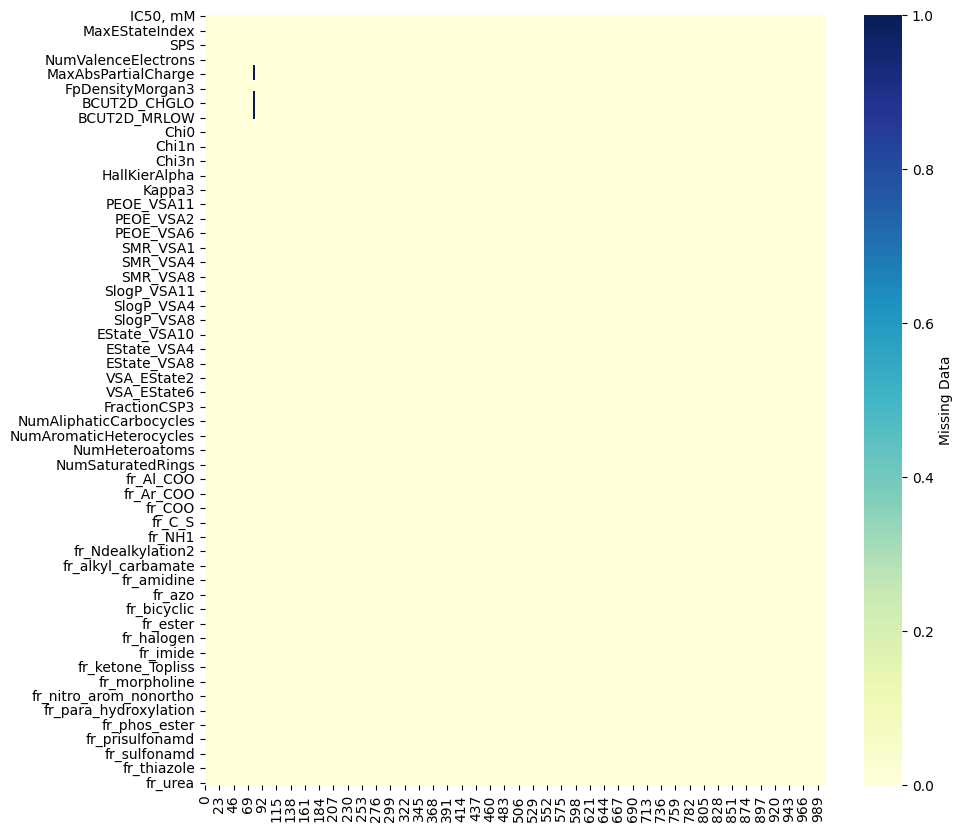

In [55]:
plt.figure(figsize=(10,10))
sns.heatmap(df.isna().transpose(),
            cmap="YlGnBu",
            cbar_kws={'label': 'Missing Data'})
plt.savefig("visualizing_missing_data_with_heatmap_Seaborn_Python.png", dpi=100)

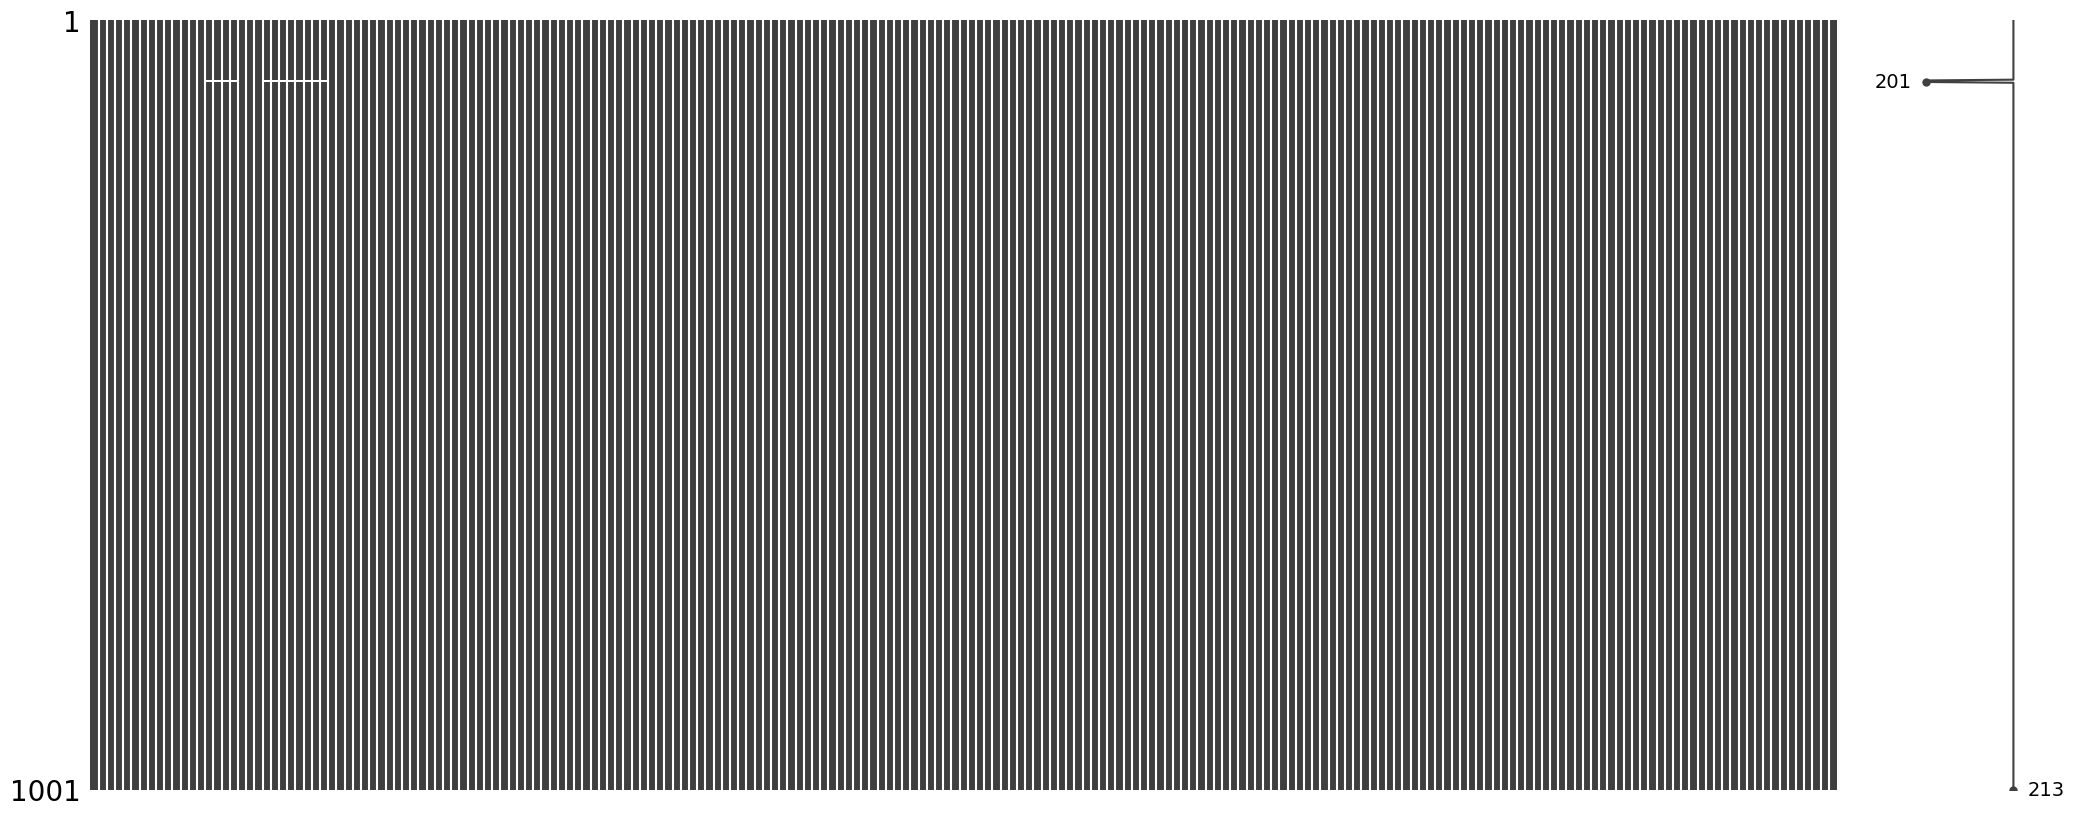

In [56]:
msno.matrix(df)
plt.savefig('missingno_matrix.png', dpi=100)

In [57]:
# Поэтому будем удалять строки с оставшимися пропусками
df_clean = df.dropna()

print(df_clean.shape)
df_clean.isna().sum().sum()

(998, 213)


np.int64(0)

##### Вывод по пропускам: 
Анализ пропущенных значений показал, что датасет практически не содержит пропущенных значений. Пропуски были обнаружены только в 12 молекулярных дескрипторах, при этом для каждого признака отсутствовало лишь по 3 значения (~0.3% выборки). Поскольку доля пропусков была крайне мала, соответствующие строки были удалены без существенной потери данных. После очистки размер выборки составил 998 объектов. Таким образом, дополнительная обработка missing values не потребовалась.

In [58]:
df.describe()


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823,10.831637,10.831637,0.180681,-0.967237,0.580412,29.487989,348.262234,...,0.053946,0.011988,0.008991,0.000999,0.000999,0.051948,0.0,0.069930,0.204795,0.006993
std,402.169734,642.867508,684.482739,3.307505,3.307505,0.168710,1.588036,0.212230,12.742749,126.946370,...,0.259011,0.108886,0.094441,0.031607,0.031607,0.222033,0.0,0.255157,1.215326,0.083373
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,12.515396,99.999036,1.433333,9.252350,9.252350,0.051073,-1.334487,0.442842,18.486486,264.321000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,46.585183,411.039342,3.846154,12.179236,12.179236,0.124606,-0.419485,0.634981,29.290323,315.457000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,224.975928,894.089176,16.566667,13.167843,13.167843,0.291020,0.061754,0.742483,38.750000,409.283000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


MolWt           ExactMolWt        0.999999
ExactMolWt      MolWt             0.999999
Chi1            HeavyAtomCount    0.998742
HeavyAtomCount  Chi1              0.998742
HeavyAtomMolWt  MolWt             0.996850
                                    ...   
SMR_VSA7        VSA_EState6       0.901585
Chi2n           Chi0n             0.901542
Chi0n           Chi2n             0.901542
VSA_EState2     fr_C_O            0.900341
fr_C_O          VSA_EState2       0.900341
Length: 298, dtype: float64


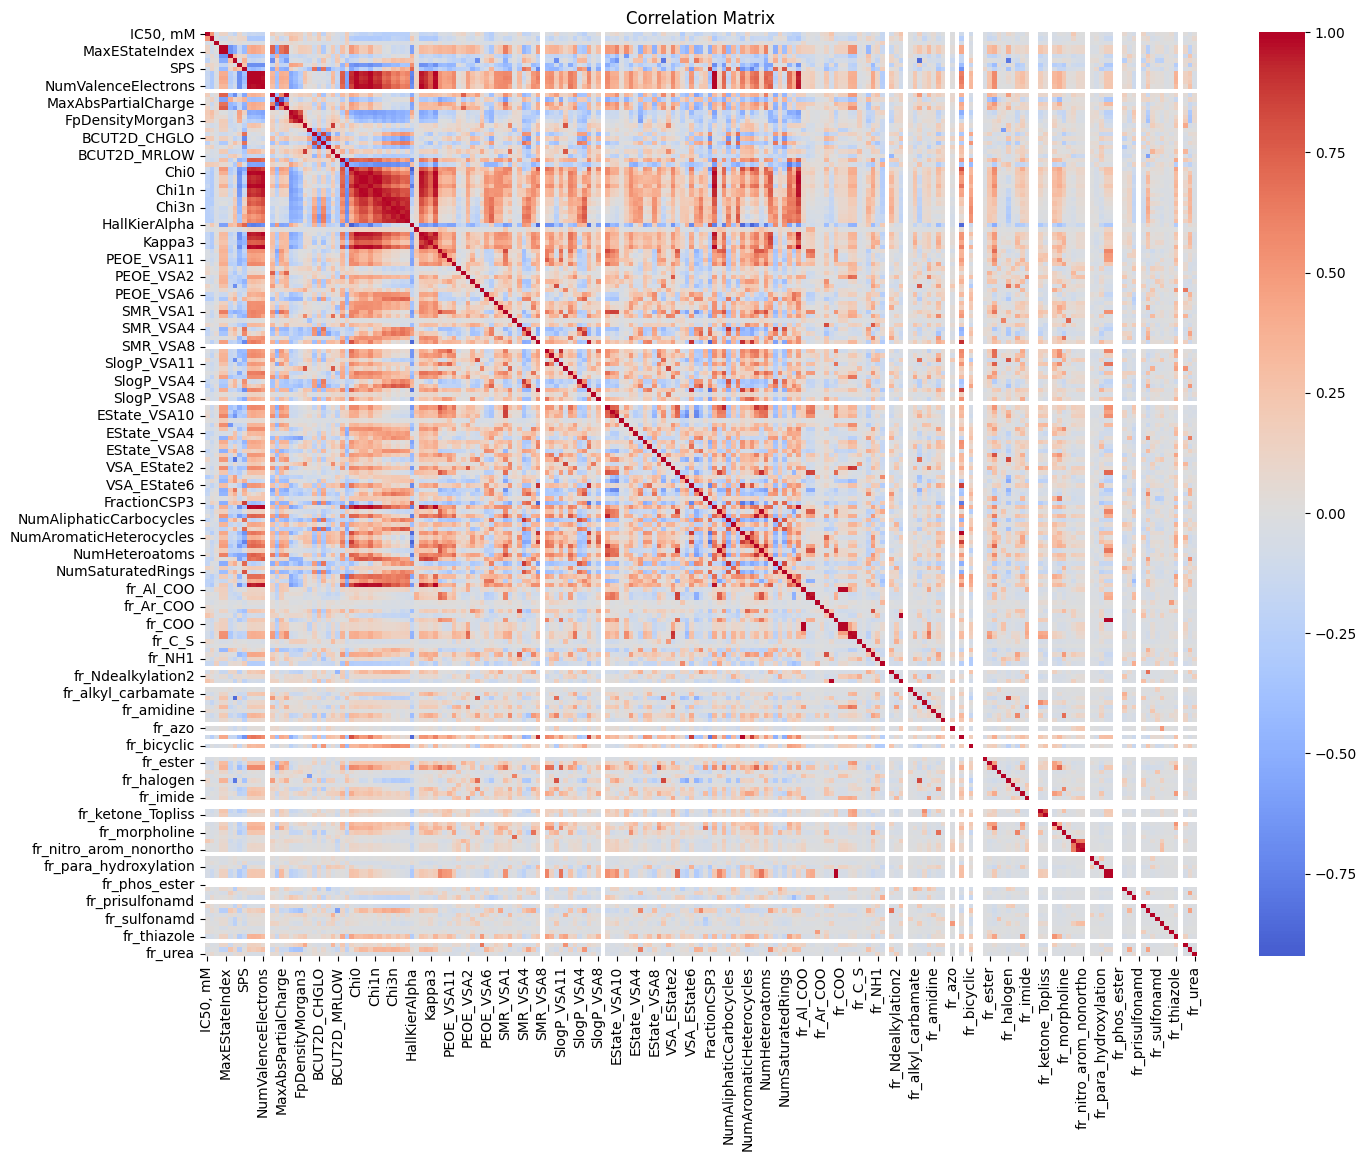

<Figure size 640x480 with 0 Axes>

In [59]:
# Взаимосвязь переменных 
# Исследование корреляций между исходными признаками

corr = df.select_dtypes(include=['number']).corr()

corr_pairs = (
    corr.abs()
        .unstack()
        .sort_values(ascending=False)
)

print(corr_pairs[(corr_pairs < 1) & (corr_pairs > 0.90)])

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.show()
plt.savefig('correlation_matrix.png',dpi=100)

##### Вывод по корреляции:
Корреляционный анализ выявил значительную мультиколлинеарность в наборе молекулярных дескрипторов. До предварительной обработки было обнаружено 298 пар признаков с коэффициентом корреляции выше 0.90. Среди них присутствовали практически идентичные дескрипторы (MolWt и ExactMolWt, Chi1 и HeavyAtomCount и др.), что свидетельствует о высокой избыточности признакового пространства.  
Для уменьшения мультиколлинеарности и снижения размерности данных были удалены признаки с корреляцией выше 0.95, после чего количество признаков сократилось с 213 до 180.

In [60]:
# Удаление высококоррелированных признаков (коэффициент корреляции > 0.95)
corr_matrix = df_clean.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

df_clean = df_clean.drop(columns=to_drop)

# Признаки, которые были удалены из-за высокой корреляции
print(to_drop)

# Размерность набора данных после удаления высококоррелированных признаков
df_clean.shape

['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MinAbsPartialCharge', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'Kappa1', 'Kappa2', 'LabuteASA', 'SlogP_VSA6', 'HeavyAtomCount', 'NumHAcceptors', 'NumHDonors', 'MolMR', 'fr_Al_OH_noTert', 'fr_COO', 'fr_COO2', 'fr_C_O_noCOO', 'fr_Nhpyrrole', 'fr_benzene', 'fr_nitro_arom_nonortho', 'fr_phenol', 'fr_phenol_noOrthoHbond']


(998, 180)

In [61]:
# отделим признаки от целевых переменных
X = df_clean.drop(columns=['IC50, mM', 'CC50, mM','SI'])
y = df_clean[['IC50, mM', 'CC50, mM','SI']]
X.shape, y.shape

((998, 177), (998, 3))

In [62]:
# Вычисление коэффициента асимметрии для каждого числового признака
skewness = X.skew()

# Сортировка признаков по абсолютному значению коэффициента асимметрии в порядке убывания
skewness = skewness.sort_values(key=abs,ascending=False)

# Вывод 20 признаков с наибольшей асимметрией
print("20 признаков с наибольшей асимметрией:")
print(skewness.head(20))

20 признаков с наибольшей асимметрией:
fr_Ar_COO            31.591138
fr_tetrazole         31.591138
fr_term_acetylene    31.591138
fr_HOCCN             31.591138
Ipc                  31.083867
fr_piperzine         21.665056
fr_epoxide           18.712680
fr_hdrzine           18.184150
fr_aldehyde          18.184150
fr_guanido           15.724090
fr_oxazole           15.724090
BCUT2D_MWLOW        -14.159349
fr_oxime             12.893944
fr_nitrile           12.799676
fr_azo               11.832125
fr_urea              11.832125
fr_amidine           11.051021
fr_sulfone           10.403038
SMR_VSA2              9.385214
fr_ArN                9.320908
dtype: float64


#### Вывод по ассиметрии:

Анализ коэффициента асимметрии показал, что многие молекулярные дескрипторы имеют крайне скошенные распределения. Для ряда признаков значение коэффициента асимметрии превышало 30, что свидетельствует о наличии длинных хвостов и большого количества редких значений. Высокие значения асимметрии объясняются тем, что многие бинарные дескрипторы, описывающие наличие определённых химических фрагментов, принимают ненулевые значения лишь для небольшого числа молекул.

In [63]:
# Удаление признаков с низкой дисперсией (вариацией)
selector = VarianceThreshold(threshold=0.01)

X_var = selector.fit_transform(X)

selected_features = X.columns[selector.get_support()]

X_clean = pd.DataFrame(X_var,columns=selected_features,index=X.index)
print(X_clean.shape)

# Вывод признаков, которые были удалены
removed_features = X.columns[~selector.get_support()]

print("Удаленные признаки:")
print(removed_features)

(998, 143)
Удаленные признаки:
Index(['NumRadicalElectrons', 'MinPartialCharge', 'MaxAbsPartialCharge',
       'SMR_VSA8', 'SlogP_VSA9', 'fr_Ar_COO', 'fr_HOCCN', 'fr_N_O', 'fr_SH',
       'fr_aldehyde', 'fr_amidine', 'fr_azide', 'fr_azo', 'fr_barbitur',
       'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_epoxide',
       'fr_guanido', 'fr_hdrzine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam',
       'fr_nitrile', 'fr_nitroso', 'fr_oxazole', 'fr_phos_acid',
       'fr_phos_ester', 'fr_prisulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiocyan', 'fr_urea'],
      dtype='object')


Высокая асимметрия указывала на наличие низковариативных и редко встречающихся признаков, поэтому для уменьшения шума и избыточности признакового пространства был применён метод VarianceThreshold для удаления низковариативных признаков. Было удалено 34 низковариативных признака. Осталось 143 признака для дальнейшего анализа и построения моделей.

In [64]:
# Вычисление коэффициента асимметрии для каждого числового признака после удаления признаков с низкой дисперсией
skewness = X_clean.skew()

skewness = skewness.sort_values(key=abs, ascending=False)

print(skewness.head(20))

Ipc                   31.083867
fr_piperzine          21.665056
BCUT2D_MWLOW         -14.159349
fr_oxime              12.893944
SMR_VSA2               9.385214
fr_ArN                 9.320908
fr_unbrch_alkane       9.214578
fr_alkyl_carbamate     8.967748
fr_nitro_arom          8.967748
fr_sulfonamd           8.967748
EState_VSA11           8.593813
fr_quatN               6.587114
fr_nitro               6.222888
fr_priamide            6.222888
SlogP_VSA7             6.005690
fr_imide               5.838940
fr_lactone             5.559392
fr_pyridine            5.512620
fr_Al_OH               5.310101
fr_sulfide             5.306305
dtype: float64


После удаления низковариативных признаков с помощью VarianceThreshold распределения молекулярных дескрипторов стали менее экстремальными. Это позволило снизить влияние шумовых и почти константных признаков, а также уменьшить избыточность признакового пространства.

In [70]:
# корреляция между признаками и целевыми переменными
# c IC50

df_clean = pd.concat([X_clean, y], axis=1)

corr_ic50 = (df_clean.corr(numeric_only=True)['IC50, mM'].drop('IC50, mM').abs().sort_values(ascending=False))

print("20 признаков с наибольшей корреляцией с IC50:")
print(corr_ic50.head(20).round(3))

20 признаков с наибольшей корреляцией с IC50:
CC50, mM                   0.523
VSA_EState4                0.272
Chi2n                      0.253
PEOE_VSA7                  0.251
fr_Ar_NH                   0.248
SlogP_VSA5                 0.232
MolLogP                    0.212
BCUT2D_LOGPHI              0.211
BCUT2D_CHGLO               0.205
FpDensityMorgan1           0.204
fr_nitro                   0.203
NumAliphaticCarbocycles    0.197
SMR_VSA4                   0.193
BalabanJ                   0.190
MinEStateIndex             0.189
VSA_EState7                0.186
FpDensityMorgan2           0.185
PEOE_VSA6                  0.183
MaxPartialCharge           0.180
EState_VSA8                0.176
Name: IC50, mM, dtype: float64


##### Вывод по корреляции с IC50: 
Корреляционный анализ показал, что наибольшая корреляция наблюдается между IC50(активность) и CC50(токсичность) 0.523 - это умеренная положительная корреляция.То есть активность и токсичность частично связаны и более активные соединения часто оказываются и более токсичными. При этом отдельные молекулярные дескрипторы имеют лишь умеренную связь с IC50 (максимальные коэффициенты корреляции около 0.27). Это свидетельствует о сложной многомерной природе зависимости между структурой молекул и биологической активностью соединений. Среди наиболее информативных признаков оказались дескрипторы, связанные с липофильностью (MolLogP, SlogP_VSA5), электронной структурой (PEOE_VSA, MaxPartialCharge) и топологическими характеристиками молекул (BalabanJ, Chi2n).

In [71]:
# корреляция между признаками и целевыми переменными
# c CC50

corr_cc50 = (df_clean.corr(numeric_only=True)['CC50, mM'].drop('CC50, mM').abs().sort_values(ascending=False))

print("20 признаков с наибольшей корреляцией с CC50:")
print(corr_cc50.head(20).round(3))

20 признаков с наибольшей корреляцией с CC50:
IC50, mM                  0.523
MolWt                     0.305
Kappa3                    0.293
FpDensityMorgan1          0.290
BertzCT                   0.263
NumAromaticCarbocycles    0.256
FpDensityMorgan2          0.254
RingCount                 0.251
Chi2n                     0.250
PEOE_VSA7                 0.248
SMR_VSA7                  0.234
MolLogP                   0.219
HallKierAlpha             0.214
SlogP_VSA3                0.208
BCUT2D_CHGLO              0.206
EState_VSA2               0.203
SlogP_VSA1                0.201
VSA_EState6               0.196
NumRotatableBonds         0.189
VSA_EState4               0.188
Name: CC50, mM, dtype: float64


##### Вывод по корреляции с СC50: 
Корреляционный анализ показал, что CC50 в большей степени связано с дескрипторами, характеризующими размер, сложность и топологию молекул (MolWt, Kappa3, BertzCT, RingCount). В отличие от IC50, где более заметную роль играли электронные и липофильные свойства, токсичность соединений оказалась сильнее связана со структурными характеристиками молекул.

In [72]:
# корреляция между признаками и целевыми переменными
# c SI

corr_si = (df_clean.corr(numeric_only=True)['SI'].drop('SI').abs().sort_values(ascending=False))

print("20 признаков с наибольшей корреляцией с SI:")
print(corr_si.head(20).round(3))

20 признаков с наибольшей корреляцией с SI:
BalabanJ                    0.165
fr_NH2                      0.160
RingCount                   0.125
fr_Al_COO                   0.102
NumAromaticRings            0.088
FpDensityMorgan1            0.088
VSA_EState4                 0.088
VSA_EState6                 0.083
NHOHCount                   0.079
NumAromaticCarbocycles      0.079
SMR_VSA7                    0.077
MolLogP                     0.076
AvgIpc                      0.076
NumAliphaticHeterocycles    0.076
BCUT2D_LOGPHI               0.075
EState_VSA2                 0.072
BertzCT                     0.070
SMR_VSA5                    0.066
fr_NH1                      0.065
fr_bicyclic                 0.065
Name: SI, dtype: float64


##### Вывод по корреляции с SI: 
Для SI значения коэффициентов корреляции оказались значительно ниже по сравнению с IC50 и CC50 (максимум 0.165), что свидетельствует об отсутствии выраженной линейной зависимости между отдельными молекулярными дескрипторами и индексом селективности. Это может быть связано с тем, что SI является производной характеристикой (SI = CC50 / IC50), зависящей одновременно от биологической активности и токсичности соединений, что делает структуру зависимости более сложной и нелинейной.

Низкие индивидуальные корреляции дескрипторов с целевыми переменными объясняют ограниченную эффективность простых линейных моделей и подтверждают целесообразность использования нелинейных ансамблевых методов (Random Forest, CatBoost, SVC).

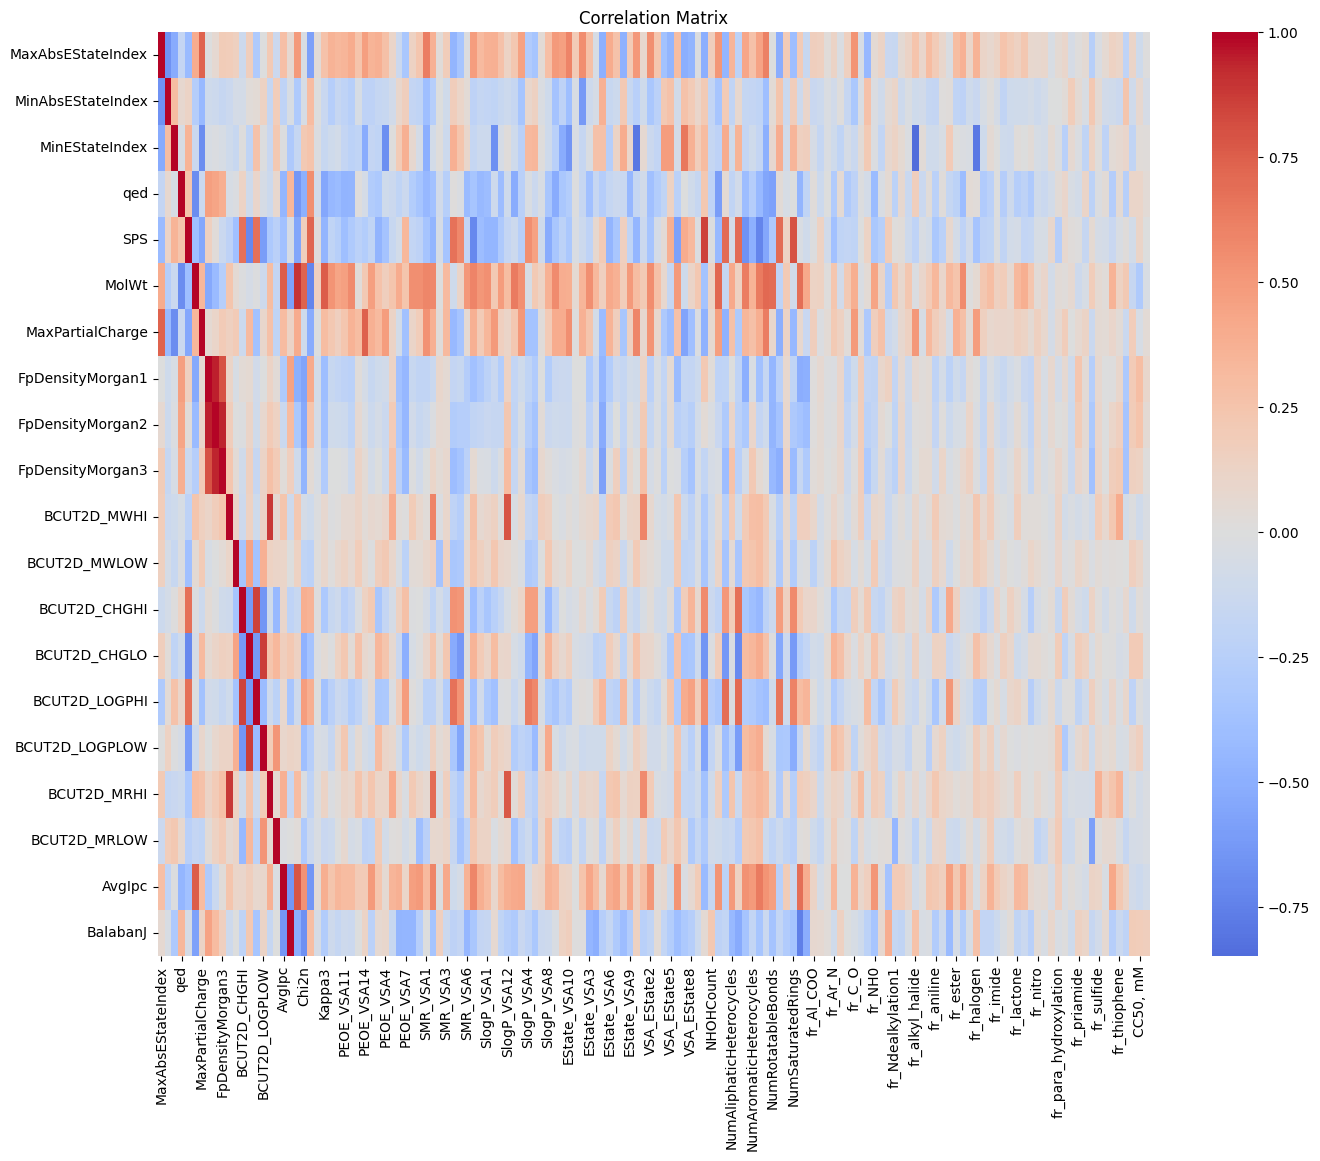

<Figure size 640x480 with 0 Axes>

In [79]:
# Heatmap корреляций наиболее информативных молекулярных дескрипторов после предварительной обработки данных и удаления низковариативных признаков
corelation_matrix = df_clean.corr(numeric_only=True).head(20)

plt.figure(figsize=(16,12))

sns.heatmap(
    corelation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.show()
plt.savefig('correlation_matrix.png',dpi=100)

##### Вывод:
После удаления низковариативных признаков структура корреляций стала более интерпретируемой. На heatmap по-прежнему наблюдаются группы умеренно коррелированных дескрипторов, отражающих сходные физико-химические и топологические свойства молекул. Это свидетельствует о сохранении определённой мультиколлинеарности даже после предварительной фильтрации признаков, поэтому на последующих этапах анализа дополнительно будут применяться методы feature selection и регуляризации (Lasso, ансамблевые модели).

In [73]:
# записываем очищенные данные в Excel файлы
X_clean.to_excel('X_data.xlsx', index=False)
y.to_excel('Y_data.xlsx', index=False)